# 03 — Results Analysis
**Project:** Optimizer and Learning Rate Study of Ovarian Cancer Prediction  
**Course:** HI 192 — Knowledge Representation and Health Decision Support

This notebook analyses the aggregated results from all 72 simulation runs. Run `src/run_all.py` first to generate `results/summary/master_results.csv`.

In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../docs/latex/figures', exist_ok=True)

RESULTS_DIR  = pathlib.Path('../results')
SUMMARY_CSV  = RESULTS_DIR / 'summary' / 'master_results.csv'

ARCHITECTURES  = ['VGG19', 'EfficientNetB3', 'ResNet50', 'DenseNet121']
OPTIMIZERS     = ['Adam', 'Adagrad', 'Adamax', 'AdaDelta', 'SGD', 'RMSProp']
LEARNING_RATES = [1e-4, 1e-5, 1e-6]
LR_LABELS      = ['1e-4', '1e-5', '1e-6']

---
## 1. Load and Display Master Results Table

Load the consolidated metrics from all 72 runs and display the full leaderboard.

In [2]:
df = pd.read_csv(SUMMARY_CSV)
df = df.sort_values('auc', ascending=False).reset_index(drop=True)
df.index += 1  # 1-based rank

print(f"Total runs loaded: {len(df)}")
pd.set_option('display.max_rows', 90)
pd.set_option('display.float_format', '{:.4f}'.format)
display(df)

Total runs loaded: 84


,run_name,architecture,optimizer,learning_rate,accuracy,precision,recall,specificity,f1,auc,epochs_run
1,VGG19_Adam_LR1e-04,VGG19,Adam,0.0001,0.7733,1.0000,0.5591,1.0000,0.7172,0.9995,26
2,VGG19_Adamax_LR1e-04,VGG19,Adamax,0.0001,0.9717,0.9918,0.9528,0.9917,0.9719,0.9995,50
3,VGG19_Nadam_LR1e-04,VGG19,Nadam,0.0001,0.8826,1.0000,0.7717,1.0000,0.8711,0.9991,26
4,DenseNet121_Adam_LR1e-04,DenseNet121,Adam,0.0001,0.9676,1.0000,0.9370,1.0000,0.9675,0.9991,27
5,DenseNet121_RMSProp_LR1e-04,DenseNet121,RMSProp,0.0001,0.9595,1.0000,0.9213,1.0000,0.9590,0.9990,24
6,DenseNet121_Nadam_LR1e-04,DenseNet121,Nadam,0.0001,0.9676,0.9612,0.9764,0.9583,0.9688,0.9978,19
7,DenseNet121_Adamax_LR1e-04,DenseNet121,Adamax,0.0001,0.9231,0.8699,1.0000,0.8417,0.9304,0.9977,23
8,VGG19_RMSProp_LR1e-04,VGG19,RMSProp,0.0001,0.8178,1.0000,0.6457,1.0000,0.7847,0.9949,21
9,ResNet50_RMSProp_LR1e-04,ResNet50,RMSProp,0.0001,0.9514,1.0000,0.9055,1.0000,0.9504,0.9943,40
10,VGG19_RMSProp_LR1e-05,VGG19,RMSProp,0.0000,0.9312,0.9583,0.9055,0.9583,0.9312,0.9933,50


---
## 2. Best Model per Architecture

For each of the 4 base architectures, identify the single best-performing configuration (optimizer + LR) by AUC-ROC.

In [3]:
# TODO: Group by architecture, select row with max AUC
best_per_arch = (
    df.reset_index(names='rank')
    .sort_values('auc', ascending=False)
    .groupby('architecture', sort=False)
    .first()
    .reset_index()
    [['architecture', 'optimizer', 'learning_rate', 'accuracy', 'precision',
      'recall', 'specificity', 'f1', 'auc']]
    .sort_values('auc', ascending=False)
)
print("Best model per architecture (ranked by AUC):")
display(best_per_arch)

Best model per architecture (ranked by AUC):


,architecture,optimizer,learning_rate,accuracy,precision,recall,specificity,f1,auc
0,VGG19,Adam,0.0001,0.7733,1.0000,0.5591,1.0000,0.7172,0.9995
1,DenseNet121,Adam,0.0001,0.9676,1.0000,0.9370,1.0000,0.9675,0.9991
2,ResNet50,RMSProp,0.0001,0.9514,1.0000,0.9055,1.0000,0.9504,0.9943
3,EfficientNetB3,RMSProp,0.0001,0.8462,1.0000,0.7008,1.0000,0.8241,0.9841


---
## 3. Best Model per Optimizer

Identify the best-performing architecture + LR for each optimizer.

In [4]:
# TODO: Group by optimizer, select row with max AUC
best_per_opt = (
    df.reset_index(names='rank')
    .sort_values('auc', ascending=False)
    .groupby('optimizer', sort=False)
    .first()
    .reset_index()
    [['optimizer', 'architecture', 'learning_rate', 'accuracy', 'precision',
      'recall', 'specificity', 'f1', 'auc']]
    .sort_values('auc', ascending=False)
)
print("Best model per optimizer (ranked by AUC):")
display(best_per_opt)

Best model per optimizer (ranked by AUC):


,optimizer,architecture,learning_rate,accuracy,precision,recall,specificity,f1,auc
0,Adam,VGG19,0.0001,0.7733,1.0000,0.5591,1.0000,0.7172,0.9995
1,Adamax,VGG19,0.0001,0.9717,0.9918,0.9528,0.9917,0.9719,0.9995
2,Nadam,VGG19,0.0001,0.8826,1.0000,0.7717,1.0000,0.8711,0.9991
3,RMSProp,DenseNet121,0.0001,0.9595,1.0000,0.9213,1.0000,0.9590,0.9990
4,SGD,DenseNet121,0.0001,0.8178,1.0000,0.6457,1.0000,0.7847,0.9885
5,Adagrad,DenseNet121,0.0001,0.4939,1.0000,0.0157,1.0000,0.0310,0.8734
6,AdaDelta,EfficientNetB3,0.0000,0.5668,0.9545,0.1654,0.9917,0.2819,0.8531


---
## 4. Best Model per Learning Rate

Identify the best-performing architecture + optimizer for each learning rate.

In [5]:
# TODO: Group by learning_rate, select row with max AUC
best_per_lr = (
    df.reset_index(names='rank')
    .sort_values('auc', ascending=False)
    .groupby('learning_rate', sort=False)
    .first()
    .reset_index()
    [['learning_rate', 'architecture', 'optimizer', 'accuracy', 'precision',
      'recall', 'specificity', 'f1', 'auc']]
    .sort_values('auc', ascending=False)
)
print("Best model per learning rate (ranked by AUC):")
display(best_per_lr)

Best model per learning rate (ranked by AUC):


,learning_rate,architecture,optimizer,accuracy,precision,recall,specificity,f1,auc
0,0.0001,VGG19,Adam,0.7733,1.0000,0.5591,1.0000,0.7172,0.9995
1,0.0000,VGG19,RMSProp,0.9312,0.9583,0.9055,0.9583,0.9312,0.9933
2,0.0000,VGG19,Adamax,0.8016,0.8482,0.7480,0.8583,0.7950,0.8713


---
## 5. Accuracy Heatmap (Optimizer × Learning Rate, one per Architecture)

Four heatmaps — one per architecture — showing mean accuracy for each optimizer × LR combination.

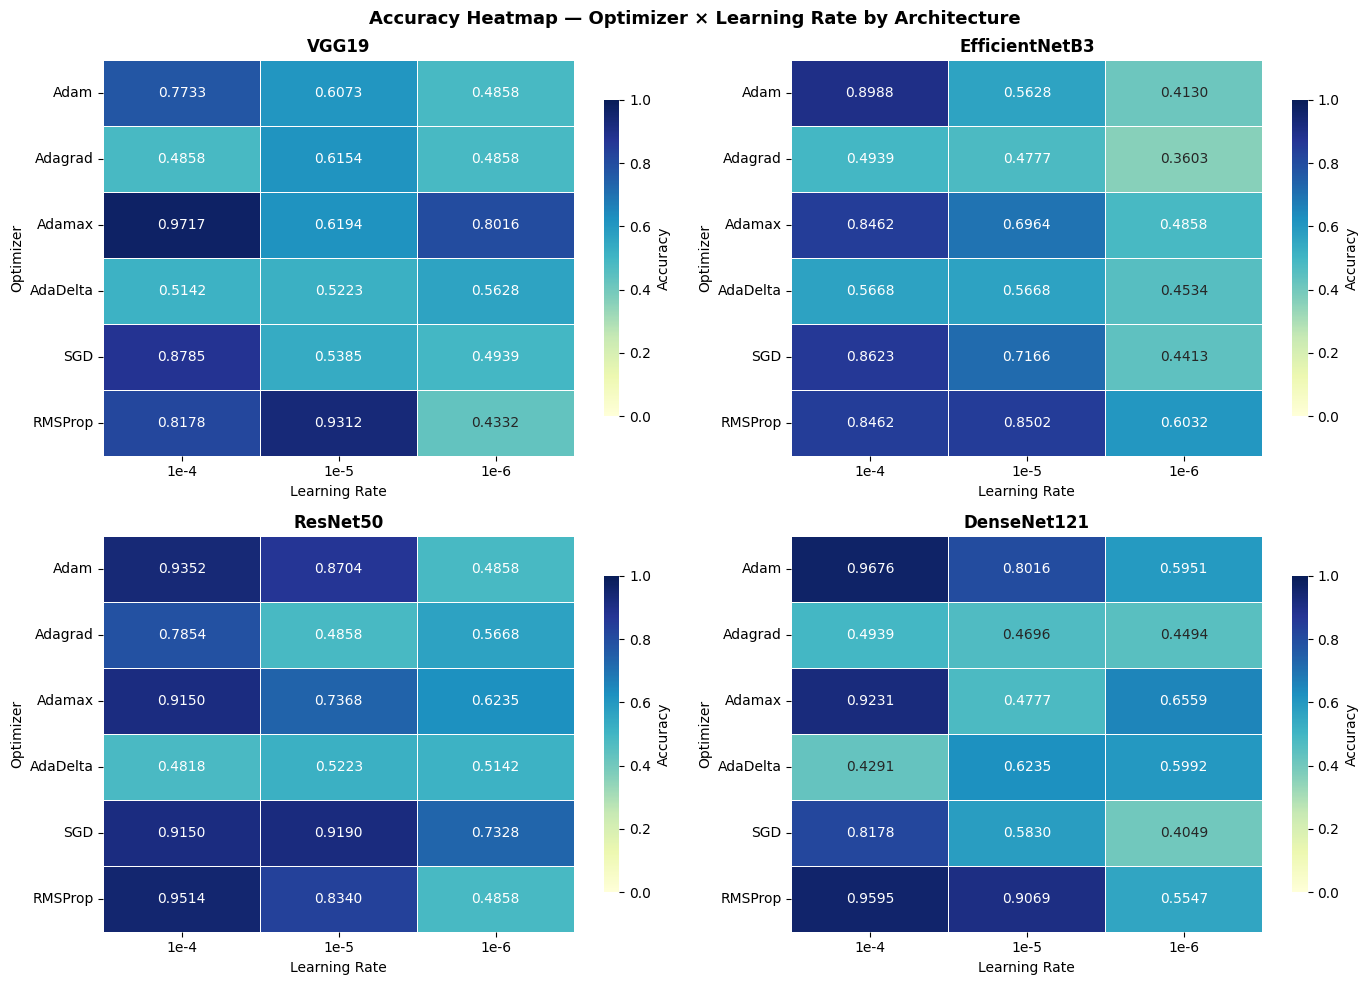

In [6]:
df['lr_label'] = df['learning_rate'].map({1e-4: '1e-4', 1e-5: '1e-5', 1e-6: '1e-6'})

df_plot = df[df['optimizer'] != 'Nadam'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, arch in enumerate(ARCHITECTURES):
    sub = df_plot[df_plot['architecture'] == arch].copy()
    pivot = sub.pivot_table(index='optimizer', columns='lr_label', values='accuracy', aggfunc='mean')
    pivot = pivot.reindex(index=OPTIMIZERS, columns=LR_LABELS)

    sns.heatmap(
        pivot,
        ax=axes[idx],
        annot=True,
        fmt='.4f',
        cmap='YlGnBu',
        vmin=0,
        vmax=1,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8, 'label': 'Accuracy'},
    )
    axes[idx].set_title(arch, fontweight='bold')
    axes[idx].set_xlabel('Learning Rate')
    axes[idx].set_ylabel('Optimizer')

fig.suptitle('Accuracy Heatmap — Optimizer × Learning Rate by Architecture',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary' / 'heatmap_accuracy.png', dpi=150, bbox_inches='tight')
plt.savefig('../docs/latex/figures/accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. AUC Heatmap (Optimizer × Learning Rate, one per Architecture)

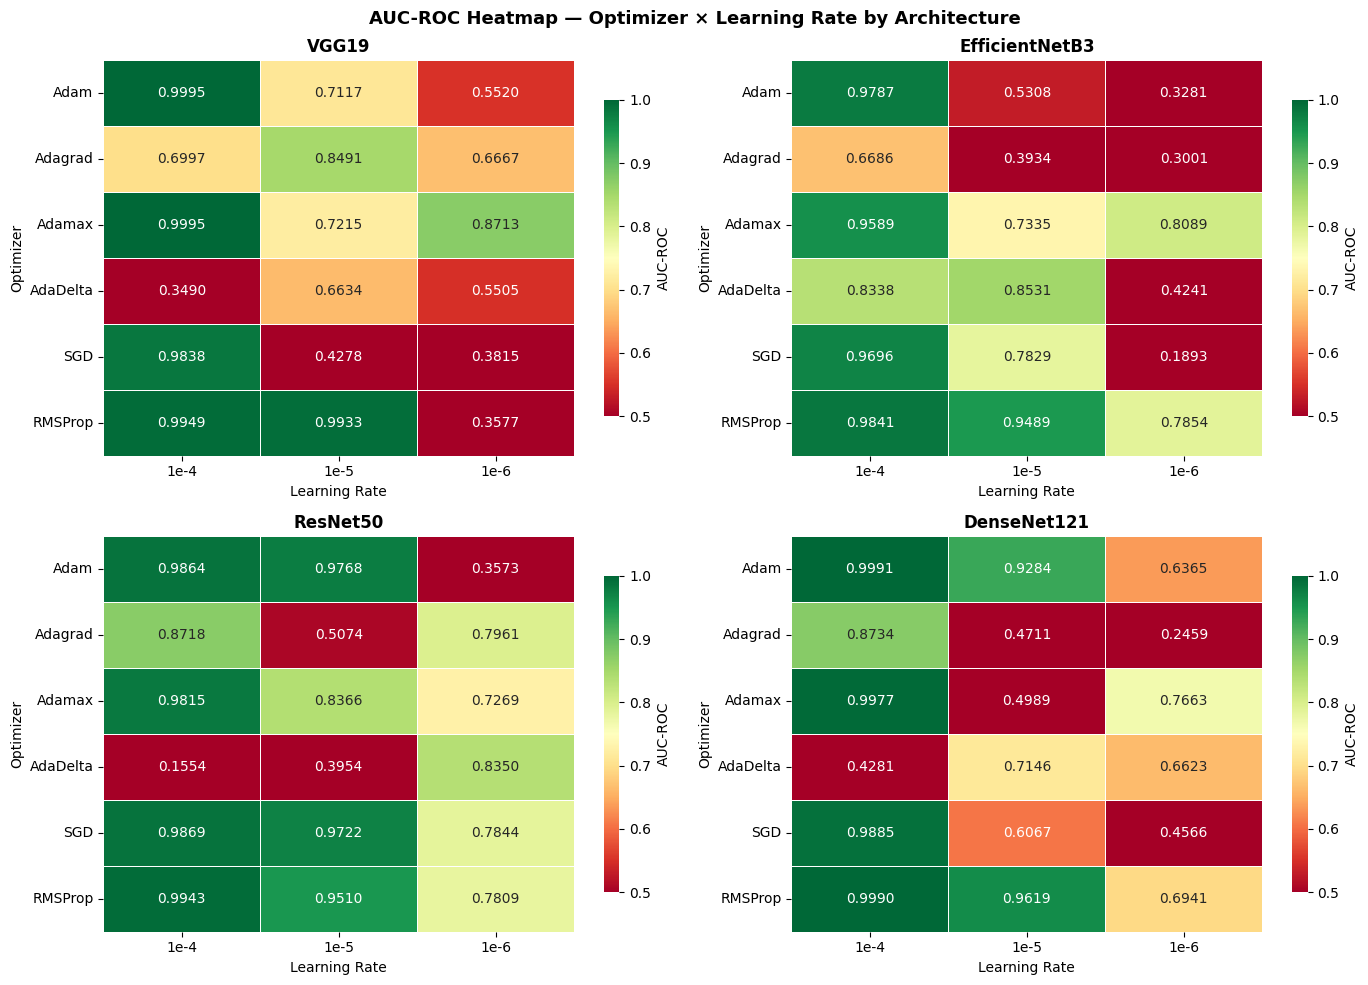

In [7]:
df_plot = df[df['optimizer'] != 'Nadam'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, arch in enumerate(ARCHITECTURES):
    sub = df_plot[df_plot['architecture'] == arch].copy()
    pivot = sub.pivot_table(index='optimizer', columns='lr_label', values='auc', aggfunc='mean')
    pivot = pivot.reindex(index=OPTIMIZERS, columns=LR_LABELS)

    sns.heatmap(
        pivot,
        ax=axes[idx],
        annot=True,
        fmt='.4f',
        cmap='RdYlGn',
        vmin=0.5,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8, 'label': 'AUC-ROC'},
    )
    axes[idx].set_title(arch, fontweight='bold')
    axes[idx].set_xlabel('Learning Rate')
    axes[idx].set_ylabel('Optimizer')

fig.suptitle('AUC-ROC Heatmap — Optimizer × Learning Rate by Architecture',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary' / 'heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.savefig('../docs/latex/figures/auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Discussion Prompts

Use the following guiding questions to structure the written analysis in `docs/latex/sections/07_discussion.tex`:

1. **Optimizer effect:** Which optimizer achieved the highest mean AUC across all architectures and learning rates? Was there a consistent winner, or did performance vary by architecture?
2. **Adaptive vs. non-adaptive:** Did adaptive optimizers (Adam, Adamax, Adagrad, AdaDelta, RMSProp) consistently outperform SGD? At which learning rates did SGD become competitive?
3. **Learning rate sensitivity:** How sensitive was each architecture to the choice of learning rate? Which architectures degraded most with LR = 1e-6?
4. **Architecture ranking:** Which base model produced the best median AUC across all 18 of its runs? Which was the most stable (lowest variance across LR/optimizer combos)?
5. **Overfitting indicators:** Do the accuracy/loss curves show signs of overfitting (training accuracy >> validation accuracy)? How does dropout rate interact with optimizer choice?
6. **Precision vs. Recall trade-off:** In a clinical context (ovarian cancer detection), which is more costly — a false negative (missed cancer) or a false positive (unnecessary biopsy)? Which model configuration best satisfies the clinical priority?
7. **Specificity:** Are there configurations with high recall but low specificity? What does that imply for clinical deployment?
8. **Reproducibility:** How does fixing `RANDOM_SEED = 42` and sharing one data split strengthen the validity of the comparison?